# Домашнее задание 4: PWM and Markov Models

In [1]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 16.6 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from Bio import SeqIO, motifs
from Bio.Seq import Seq
import warnings
warnings.filterwarnings('ignore')

BACKGROUND = {'A': 0.295, 'C': 0.205, 'G': 0.205, 'T': 0.295}
NUCLEOTIDES = ['A', 'C', 'G', 'T']
BG_PROBS = np.array([BACKGROUND[n] for n in NUCLEOTIDES])

---
# Часть I: Моделирование мотивов и PWM

## Задание 1. Реализация PWM «с нуля»

In [3]:
sites = [
    "GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA",
    "ACAGTCAGC", "TAGGTCAGC", "CAGGTCAGC",
    "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC",
    "CAGGTTGGC"
]
L = len(sites[0])
N = len(sites)

**PFM** — считаем, сколько раз каждый нуклеотид встречается на каждой позиции.

In [4]:
def compute_pfm(sites):
    L = len(sites[0])
    pfm = np.zeros((4, L), dtype=float)
    nuc_idx = {n: i for i, n in enumerate(NUCLEOTIDES)}
    for seq in sites:
        for pos, nuc in enumerate(seq):
            pfm[nuc_idx[nuc], pos] += 1
    return pfm

pfm = compute_pfm(sites)
print('PFM (строки: A,C,G,T | столбцы: позиции 1..9):')
print(pfm)

PFM (строки: A,C,G,T | столбцы: позиции 1..9):
[[ 1.  8.  1.  0.  0.  2.  7.  2.  1.]
 [ 6.  2.  1.  0.  0.  6.  0.  0.  8.]
 [ 1.  0.  8. 10.  0.  0.  3.  8.  0.]
 [ 2.  0.  0.  0. 10.  2.  0.  0.  1.]]


**PPM** — нормализуем PFM в вероятности, добавляя псевдосчёт α=0.1, чтобы избежать нулевых вероятностей:

$$PPM_{b,i} = \frac{count_{b,i} + \alpha}{N + 4\alpha}$$

In [5]:
def pfm_to_ppm(pfm, alpha=0.1):
    N = pfm.sum(axis=0)
    return (pfm + alpha) / (N + 4 * alpha)

ppm = pfm_to_ppm(pfm)
np.set_printoptions(precision=4)
print('PPM:')
print(ppm)
print('Суммы по столбцам:', ppm.sum(axis=0).round(6))

PPM:
[[0.1058 0.7788 0.1058 0.0096 0.0096 0.2019 0.6827 0.2019 0.1058]
 [0.5865 0.2019 0.1058 0.0096 0.0096 0.5865 0.0096 0.0096 0.7788]
 [0.1058 0.0096 0.7788 0.9712 0.0096 0.0096 0.2981 0.7788 0.0096]
 [0.2019 0.0096 0.0096 0.0096 0.9712 0.2019 0.0096 0.0096 0.1058]]
Суммы по столбцам: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


**PWM** — логарифм отношения вероятности к фону. Положительное значение означает, что нуклеотид встречается чаще случайного, отрицательное — реже:

$$PWM_{b,i} = \log_2\frac{PPM_{b,i}}{background_b}$$

In [6]:
def ppm_to_pwm(ppm, background=BACKGROUND):
    bg = np.array([background[n] for n in NUCLEOTIDES]).reshape(-1, 1)
    return np.log2(ppm / bg)

pwm = ppm_to_pwm(ppm)
print('PWM (log-odds):')
print(pwm)

PWM (log-odds):
[[-1.4798  1.4006 -1.4798 -4.9392 -4.9392 -0.5469  1.2105 -0.5469 -1.4798]
 [ 1.5166 -0.0218 -0.9547 -4.4141 -4.4141  1.5166 -4.4141 -4.4141  1.9257]
 [-0.9547 -4.4141  1.9257  2.2441 -4.4141 -4.4141  0.5401  1.9257 -4.4141]
 [-0.5469 -4.9392 -4.9392 -4.9392  1.719  -0.5469 -4.9392 -4.9392 -1.4798]]


Максимальный скор достигается, если на каждой позиции выбрать нуклеотид с наибольшим весом, минимальный — с наименьшим.

In [7]:
def score_sequence(seq, pwm):
    nuc_idx = {n: i for i, n in enumerate(NUCLEOTIDES)}
    return sum(pwm[nuc_idx[nuc], pos] for pos, nuc in enumerate(seq))

max_seq = ''.join(NUCLEOTIDES[i] for i in pwm.argmax(axis=0))
min_seq = ''.join(NUCLEOTIDES[i] for i in pwm.argmin(axis=0))

print(f'Максимальный скор: {pwm.max(axis=0).sum():.4f}  →  {max_seq}')
print(f'Минимальный скор:  {pwm.min(axis=0).sum():.4f}  →  {min_seq}')

Максимальный скор: 15.3846  →  CAGGTCAGC
Минимальный скор:  -39.9434  →  ATTAAGTTG


## Задание 2. Сканирование хромосомы человека

In [8]:
CHR1_PATH = 'chr1.fa'

import urllib.request, gzip, shutil
urllib.request.urlretrieve(
    'https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr1.fa.gz',
    'chr1.fa.gz'
)
with gzip.open('chr1.fa.gz', 'rb') as f_in, open(CHR1_PATH, 'wb') as f_out:
    shutil.copyfileobj(f_in, f_out)

In [9]:
bio_sites = [Seq(s) for s in sites]
m = motifs.create(bio_sites)
m.background = BACKGROUND

record = next(SeqIO.parse(CHR1_PATH, 'fasta'))
sequence = record.seq[:1_000_000]

print(f'Мотив: {m.consensus}')
print(f'Загружено {len(sequence):,} нуклеотидов')

Мотив: CAGGTCAGC
Загружено 1,000,000 нуклеотидов


Транскрипционные факторы могут связываться на обеих цепях ДНК, поэтому ищем и на прямой, и на обратно-комплементарной.

In [10]:
THRESHOLD = 5.0
pssm = m.pssm
hits = []

for pos, score in pssm.search(sequence, threshold=THRESHOLD):
    hits.append((pos, '+', round(score, 4)))

for pos, score in pssm.reverse_complement().search(sequence, threshold=THRESHOLD):
    hits.append((pos, '-', round(score, 4)))

hits.sort(key=lambda x: x[0])

print(f'Найдено хитов (score > {THRESHOLD}): {len(hits)}')
print('\nПервые 20:')
for h in hits[:20]:
    print(f'  pos={h[0]:>8},  strand={h[1]},  score={h[2]:.4f}')

Найдено хитов (score > 5.0): 3084

Первые 20:
  pos= -989500,  strand=+,  score=12.2002
  pos= -988998,  strand=+,  score=8.4430
  pos= -988679,  strand=+,  score=5.5051
  pos= -988132,  strand=+,  score=7.5650
  pos= -988124,  strand=-,  score=8.6654
  pos= -988109,  strand=+,  score=7.0901
  pos= -987988,  strand=+,  score=6.0901
  pos= -987776,  strand=-,  score=5.0901
  pos= -987324,  strand=+,  score=11.5029
  pos= -986866,  strand=+,  score=9.3928
  pos= -986670,  strand=-,  score=7.0901
  pos= -986540,  strand=-,  score=6.8078
  pos= -986133,  strand=-,  score=6.9800
  pos= -985944,  strand=-,  score=5.4527
  pos= -985759,  strand=+,  score=8.1403
  pos= -985720,  strand=-,  score=15.7252
  pos= -984852,  strand=-,  score=8.6152
  pos= -983992,  strand=+,  score=5.5051
  pos= -983885,  strand=+,  score=6.0901
  pos= -983149,  strand=+,  score=6.2827


## Задание 3. Эмпирическое распределение и p-value

In [11]:
np.random.seed(42)
N_RANDOM = 100_000

rand_seqs = np.random.choice(4, size=(N_RANDOM, L), p=BG_PROBS)
scores = np.sum(pwm[rand_seqs, np.arange(L)], axis=1)

print(f'Средний скор: {scores.mean():.4f}')
print(f'Макс: {scores.max():.4f},  Мин: {scores.min():.4f}')

Средний скор: -16.5902
Макс: 12.6506,  Мин: -39.9434


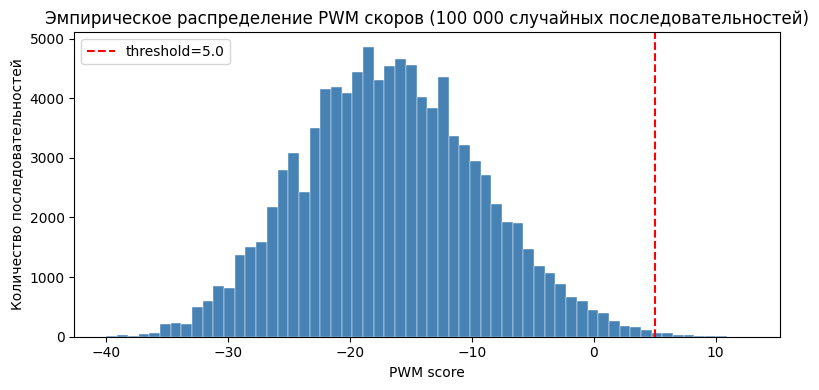

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(x=5.0, color='red', linestyle='--', label='threshold=5.0')
ax.set_xlabel('PWM score')
ax.set_ylabel('Количество последовательностей')
ax.set_title('Эмпирическое распределение PWM скоров (100 000 случайных последовательностей)')
ax.legend()
plt.tight_layout()
plt.show()

Порог для p-value ≈ 10⁻⁴ — это 99.99-й процентиль распределения фоновых скоров.

In [13]:
def get_pvalue(score, background_scores=scores):
    return (background_scores >= score).mean()

threshold_1e4 = np.sort(scores)[int(N_RANDOM * (1 - 1e-4))]

print(f'Порог для p-value ≈ 1e-4: {threshold_1e4:.4f}')
print(f'Проверка: p-value = {get_pvalue(threshold_1e4):.2e}')

for s in [3.0, 4.0, 5.0, threshold_1e4]:
    print(f'  p-value({s:.3f}) = {get_pvalue(s):.2e}')

Порог для p-value ≈ 1e-4: 10.5566
Проверка: p-value = 1.00e-04
  p-value(3.000) = 5.07e-03
  p-value(4.000) = 3.32e-03
  p-value(5.000) = 2.18e-03
  p-value(10.557) = 1.00e-04
